In [4]:
!pip install statsmodels


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm



In [7]:
df = pd.read_csv('../../data/raw/Life Expectancy Data.csv')


In [8]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# 정보 확인
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under_five_deaths                2938 non-null   int64  
 12  Polio               

In [13]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('/', '_')


In [14]:
df.columns.tolist()


['Country',
 'Year',
 'Status',
 'Life_expectancy',
 'Adult_Mortality',
 'infant_deaths',
 'Alcohol',
 'percentage_expenditure',
 'Hepatitis_B',
 'Measles',
 'BMI',
 'under_five_deaths',
 'Polio',
 'Total_expenditure',
 'Diphtheria',
 'HIV_AIDS',
 'GDP',
 'Population',
 'thinness__1_19_years',
 'thinness_5_9_years',
 'Income_composition_of_resources',
 'Schooling']

In [15]:
# Status 인코딩
df['Status'] = df['Status'].map({'Developing': 0, 'Developed': 1})

# 타겟 분리
y = df['Life_expectancy']

# 입력 변수
X = df.drop(['Life_expectancy', 'Country', 'Year'], axis=1)

# 결측치 처리
X = X.fillna(X.mean())
y = y.fillna(y.mean())


In [16]:
X.head()

,Status,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Population,thinness__1_19_years,thinness_5_9_years,Income_composition_of_resources,Schooling
0,NaN,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,NaN,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,NaN,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,NaN,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,NaN,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [20]:
# 결측치 평균값으로 대체
X = X.fillna(X.mean())
y = y.fillna(y.mean())


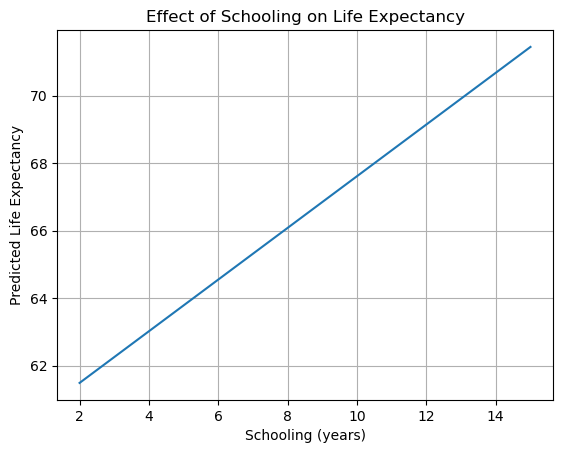

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 평균값 가정 (데이터 평균으로 바꿔도 됨)
BMI = 22
HIV = 1
GDP = 8000
Polio = 85
Year = 2010

# Schooling 범위
schooling = np.linspace(2, 15, 100)

# 회귀식
life_exp = (
    -82.9872
    + 0.6758 * BMI
    - 1.5499 * HIV
    + 0.0001 * GDP
    + 0.7658 * schooling
    + 0.1843 * Polio
    + 0.0563 * Year
)

# 그래프
plt.figure()
plt.plot(schooling, life_exp)
plt.xlabel("Schooling (years)")
plt.ylabel("Predicted Life Expectancy")
plt.title("Effect of Schooling on Life Expectancy")
plt.grid(True)
plt.show()


In [22]:
import pandas as pd

df = pd.read_csv("data/raw/Life Expectancy Data.csv")
df.head()


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [23]:
df.columns = df.columns.str.strip()


In [24]:
import pandas as pd

df = pd.read_csv("data/raw/Life Expectancy Data.csv")

# 컬럼 이름 공백 제거
df.columns = df.columns.str.strip()

df.columns


Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [25]:
BMI = df['BMI'].mean()
HIV = df['HIV/AIDS'].mean()


In [19]:
df.columns = df.columns.str.strip()


In [32]:
print(BMI)
print(HIV)
print(GDP)
print(Schooling)
print(Polio)
print(Year)



38.321246556473824
1.7421034717494894
7483.158469138474
11.992792792792793
82.55018842069202
2007.5187202178352


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 사용할 변수 선택
features = ['BMI', 'HIV/AIDS', 'GDP', 'Schooling', 'Polio', 'Year']
target = 'Life expectancy'

# X, y 설정
X = df[features]
y = df[target]

# 결측치 제거
data = pd.concat([X, y], axis=1).dropna()
X = data[features]
y = data[target]

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 선형회귀 모델 생성
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 성능 평가
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² score:", r2)
print("RMSE:", rmse)

# 회귀계수 출력
print("\n회귀계수:")
for name, coef in zip(features, model.coef_):
    print(f"{name}: {coef:.4f}")

print("\n절편 (Intercept):", model.intercept_)


R² score: 0.7920296477602116
RMSE: 4.392761772666917

회귀계수:
BMI: 0.0567
HIV/AIDS: -0.7037
GDP: 0.0001
Schooling: 1.5169
Polio: 0.0445
Year: -0.0440

절편 (Intercept): 134.30253823198103


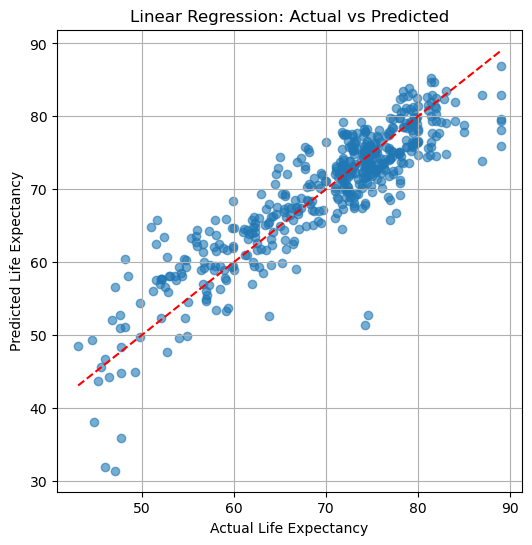

In [34]:
import matplotlib.pyplot as plt

# 실제값 vs 예측값 그래프
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

# 완벽한 예측선 (대각선)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()


In [35]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results[name] = (r2, rmse)

# 결과 출력
for model, (r2, rmse) in results.items():
    print(f"{model} → R²: {r2:.3f}, RMSE: {rmse:.3f}")


Linear Regression → R²: 0.792, RMSE: 4.393
Random Forest → R²: 0.925, RMSE: 2.639
Gradient Boosting → R²: 0.896, RMSE: 3.103


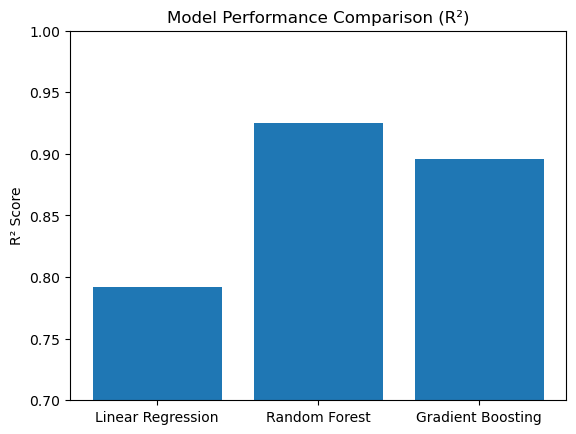

In [36]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Random Forest", "Gradient Boosting"]
r2_scores = [0.792, 0.925, 0.896]

plt.figure()
plt.bar(models, r2_scores)
plt.ylabel("R² Score")
plt.title("Model Performance Comparison (R²)")
plt.ylim(0.7, 1.0)
plt.show()


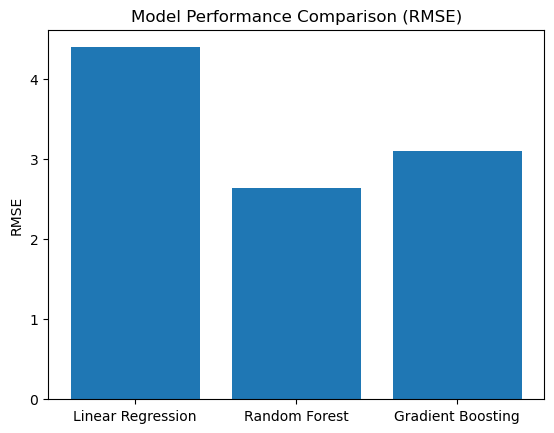

In [37]:
rmse_scores = [4.393, 2.639, 3.103]

plt.figure()
plt.bar(models, rmse_scores)
plt.ylabel("RMSE")
plt.title("Model Performance Comparison (RMSE)")
plt.show()


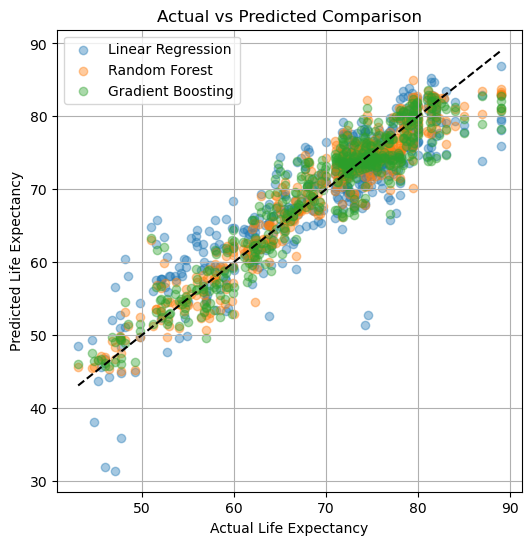

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt

# 모델 정의
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)

# 모델 학습
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# 예측
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

# 그래프
plt.figure(figsize=(6,6))

plt.scatter(y_test, lr_pred, alpha=0.4, label="Linear Regression")
plt.scatter(y_test, rf_pred, alpha=0.4, label="Random Forest")
plt.scatter(y_test, gb_pred, alpha=0.4, label="Gradient Boosting")

# 기준선
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='black',
    linestyle='--'
)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.grid(True)
plt.show()


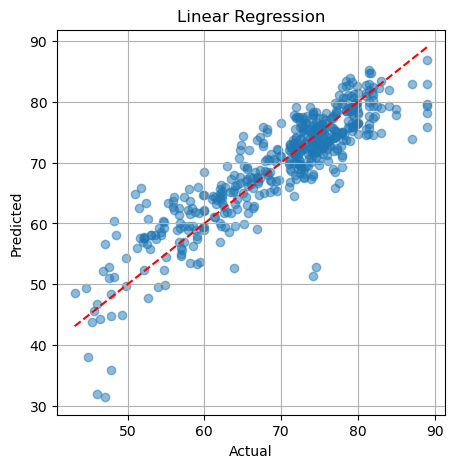

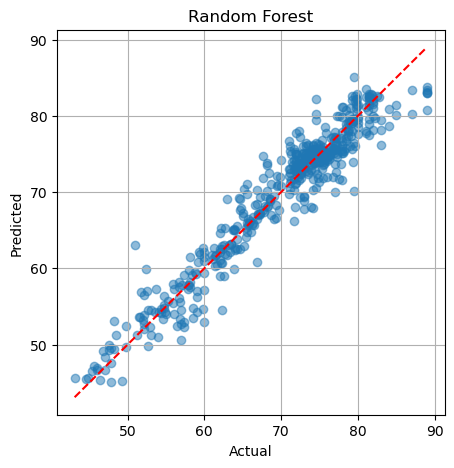

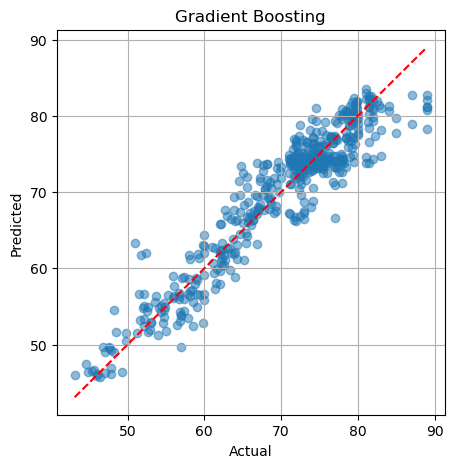

In [39]:
models = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

for name, pred in models.items():
    plt.figure(figsize=(5,5))
    plt.scatter(y_test, pred, alpha=0.5)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--'
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(name)
    plt.grid(True)
    plt.show()


In [41]:
# 컬럼명 통일
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('/', '_')

# 확인
print(df.columns.tolist())


['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria', 'HIV_AIDS', 'GDP', 'Population', 'thinness__1-19_years', 'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling']


In [42]:
# Status 인코딩
df['Status'] = df['Status'].map({'Developing': 0, 'Developed': 1})

# 타겟
y = df['Life_expectancy']

# 입력 변수
X = df.drop(['Life_expectancy', 'Country', 'Year'], axis=1)


In [43]:
y = df['Life_expectancy']


In [44]:
# 결측치 평균값으로 대체
X = X.fillna(X.mean())
y = y.fillna(y.mean())


In [45]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
feat_impt_ser = pd.Series(
    lr.coef_,
    index=X_train.columns
).sort_values(key=abs, ascending=False)


C:\Users\Playdata\AppData\Local\Temp\ipykernel_7320\1333837923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


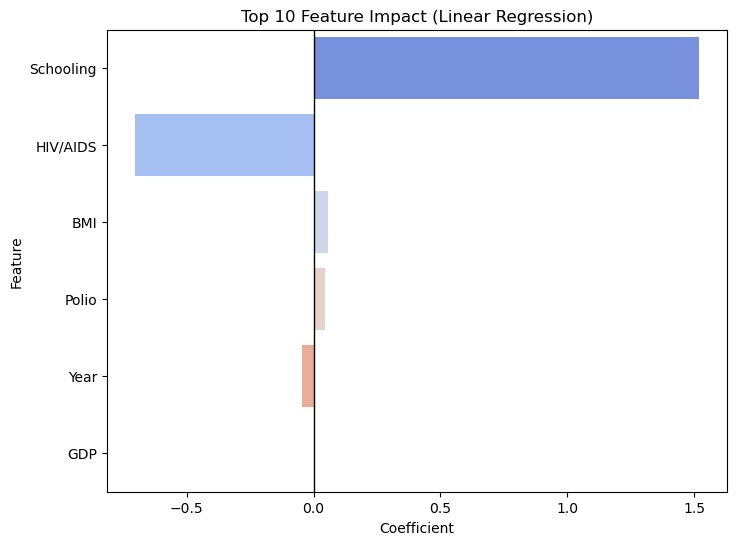

In [50]:
top10 = feat_impt_ser.head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="coolwarm"
)
plt.axvline(0, color='black', linewidth=1)
plt.title("Top 10 Feature Impact (Linear Regression)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()



In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': range(95, 105),
    'max_depth': range(8 , 12),
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', None]
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')


In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid_search = GridSearchCV(
    LinearRegression(),
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)


In [53]:
grid_search.fit(X_train,y_train)

,estimator,LinearRegression()
,param_grid,"{'fit_intercept': [True, False], 'positive': [True, False]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,fit_intercept,True


In [54]:
grid_search.best_params_


{'fit_intercept': True, 'positive': False}

In [55]:
param_grid_v2 = {
    'max_depth': [11, 15, 20, None],
    'n_estimators': [ 200, 300, 500],
    'max_features': [None, 'sqrt'], # 이미 None이 좋다고 나왔으니 고정하거나 'sqrt' 정도만 추가
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [56]:
rid_search_v2 = GridSearchCV(RandomForestRegressor(), param_grid_v2, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

In [57]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

def objective(trial):

    param = {
        'fit_intercept': trial.suggest_categorical('fit_intercept', [True, False]),
        'positive': trial.suggest_categorical('positive', [True, False])
    }

    model = LinearRegression(**param)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    ).mean()

    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"최적의 MSE 점수: {-study.best_value}")
print(f"최적의 파라미터: {study.best_params}")


[I 2026-02-10 13:20:27,828] A new study created in memory with name: no-name-746ab15a-f761-4738-963b-be8c0702d6ba
[I 2026-02-10 13:20:27,844] Trial 0 finished with value: -20.531697421925674 and parameters: {'fit_intercept': True, 'positive': False}. Best is trial 0 with value: -20.531697421925674.
[I 2026-02-10 13:20:27,859] Trial 1 finished with value: -33.49423487304887 and parameters: {'fit_intercept': True, 'positive': True}. Best is trial 0 with value: -20.531697421925674.
[I 2026-02-10 13:20:27,870] Trial 2 finished with value: -33.431175270325994 and parameters: {'fit_intercept': False, 'positive': True}. Best is trial 0 with value: -20.531697421925674.
[I 2026-02-10 13:20:27,886] Trial 3 finished with value: -20.581095547621025 and parameters: {'fit_intercept': False, 'positive': False}. Best is trial 0 with value: -20.531697421925674.
[I 2026-02-10 13:20:27,905] Trial 4 finished with value: -20.531697421925674 and parameters: {'fit_intercept': True, 'positive': False}. Best i

최적의 MSE 점수: 20.531697421925674
최적의 파라미터: {'fit_intercept': True, 'positive': False}


In [58]:
from sklearn.linear_model import LinearRegression

# 1. Optuna 최적 파라미터
best_params = study.best_params
final_model = LinearRegression(**best_params)

# 2. 전체 학습 데이터로 학습
final_model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = final_model.predict(X_test)

# 성능 지표 계산
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"최종 R2 Score: {r2:.4f}")
print(f"최종 RMSE: {rmse:.4f}")

최종 R2 Score: 0.7920
최종 RMSE: 4.3928


In [61]:
# 계수 기반 중요도
coef_ser = pd.Series(
    final_model.coef_,
    index=X_train.columns
).sort_values(key=abs, ascending=False)

print(coef_ser)


Schooling    1.516897
HIV/AIDS    -0.703653
BMI          0.056671
Polio        0.044471
Year        -0.044040
GDP          0.000076
dtype: float64


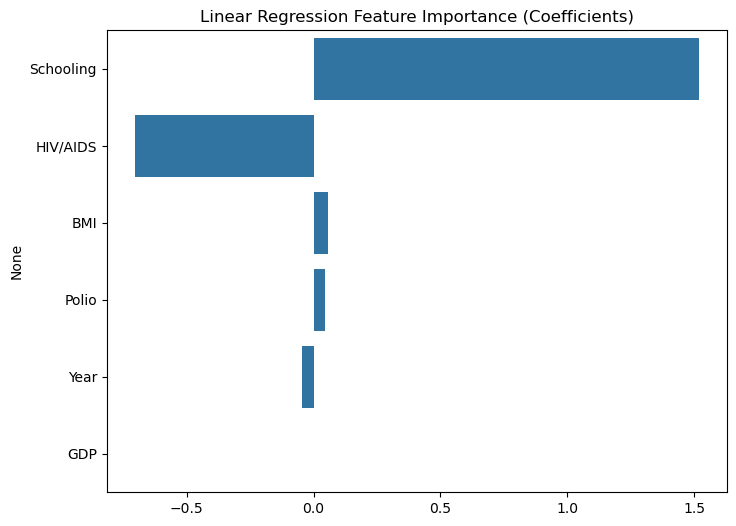

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    x=coef_ser.values,
    y=coef_ser.index
)
plt.title("Linear Regression Feature Importance (Coefficients)")
plt.show()
